# BigMart Sales – Exploratory Data Analysis

Deep dive into distributions, missing values, feature relationships, and outlet/item patterns.

# 0. Seeing Up The Env.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [6]:

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

TRAIN_PATH = 'data/train_v9rqX0R.csv'
TEST_PATH  = 'data/test_AbJTz2l.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
test['Item_Outlet_Sales'] = np.nan
combined = pd.concat([train, test], ignore_index=True, sort=False)

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
train.head()


Train : (8523, 12)
Test  : (5681, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 1 · Schema & Data Types

In [7]:
print('=== DTYPES ===')
print(train.dtypes)
print()
print('=== DESCRIBE (numeric) ===')
train.describe()


=== DTYPES ===
Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object

=== DESCRIBE (numeric) ===


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [8]:
print('=== DESCRIBE (object) ===')
train.describe(include='object')


=== DESCRIBE (object) ===


,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDG33,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


## 2 · Missing Values

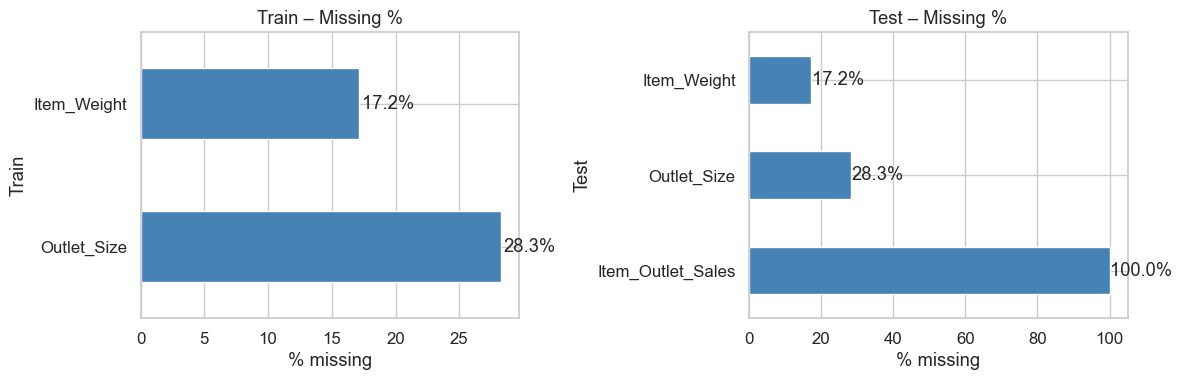

             Missing   Pct%
Train                      
Outlet_Size     2410  28.28
Item_Weight     1463  17.17


In [9]:
def missing_report(df, label=''):
    m = df.isnull().sum()
    m = m[m > 0].sort_values(ascending=False)
    pct = (m / len(df) * 100).round(2)
    return pd.DataFrame({'Missing': m, 'Pct%': pct}, index=m.index).rename_axis(label)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, lbl) in zip(axes, [(train,'Train'), (test,'Test')]):
    rpt = missing_report(df, lbl)
    if rpt.empty:
        ax.set_title(f'{lbl}: No missing')
        continue
    rpt['Pct%'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{lbl} – Missing %')
    ax.set_xlabel('% missing')
    for i, v in enumerate(rpt['Pct%']):
        ax.text(v + 0.2, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()
print(missing_report(train, 'Train'))


## 3 · Target Variable (Item_Outlet_Sales)

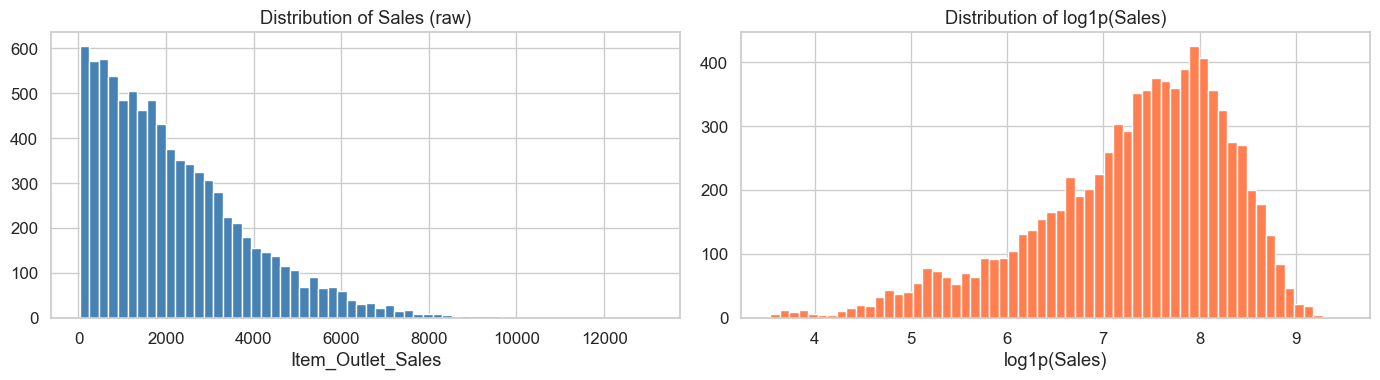

Normality test on log-target: stat=898.050, p=0.0000
count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['Item_Outlet_Sales'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Sales (raw)')
axes[0].set_xlabel('Item_Outlet_Sales')

axes[1].hist(np.log1p(train['Item_Outlet_Sales']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribution of log1p(Sales)')
axes[1].set_xlabel('log1p(Sales)')

plt.tight_layout()
plt.show()

from scipy import stats
stat, p = stats.normaltest(np.log1p(train['Item_Outlet_Sales']))
print(f'Normality test on log-target: stat={stat:.3f}, p={p:.4f}')
print(train['Item_Outlet_Sales'].describe())


## 4 · Categorical Features: Inconsistencies & Distributions

In [11]:
# Fat content inconsistency
print('Raw Item_Fat_Content values:', train['Item_Fat_Content'].value_counts().to_dict())

fat_map = {'low fat':'Low Fat','LF':'Low Fat','reg':'Regular'}
train['Item_Fat_Content'] = train['Item_Fat_Content'].replace(fat_map)
print('Cleaned:', train['Item_Fat_Content'].value_counts().to_dict())


Raw Item_Fat_Content values: {'Low Fat': 5089, 'Regular': 2889, 'LF': 316, 'reg': 117, 'low fat': 112}
Cleaned: {'Low Fat': 5517, 'Regular': 3006}


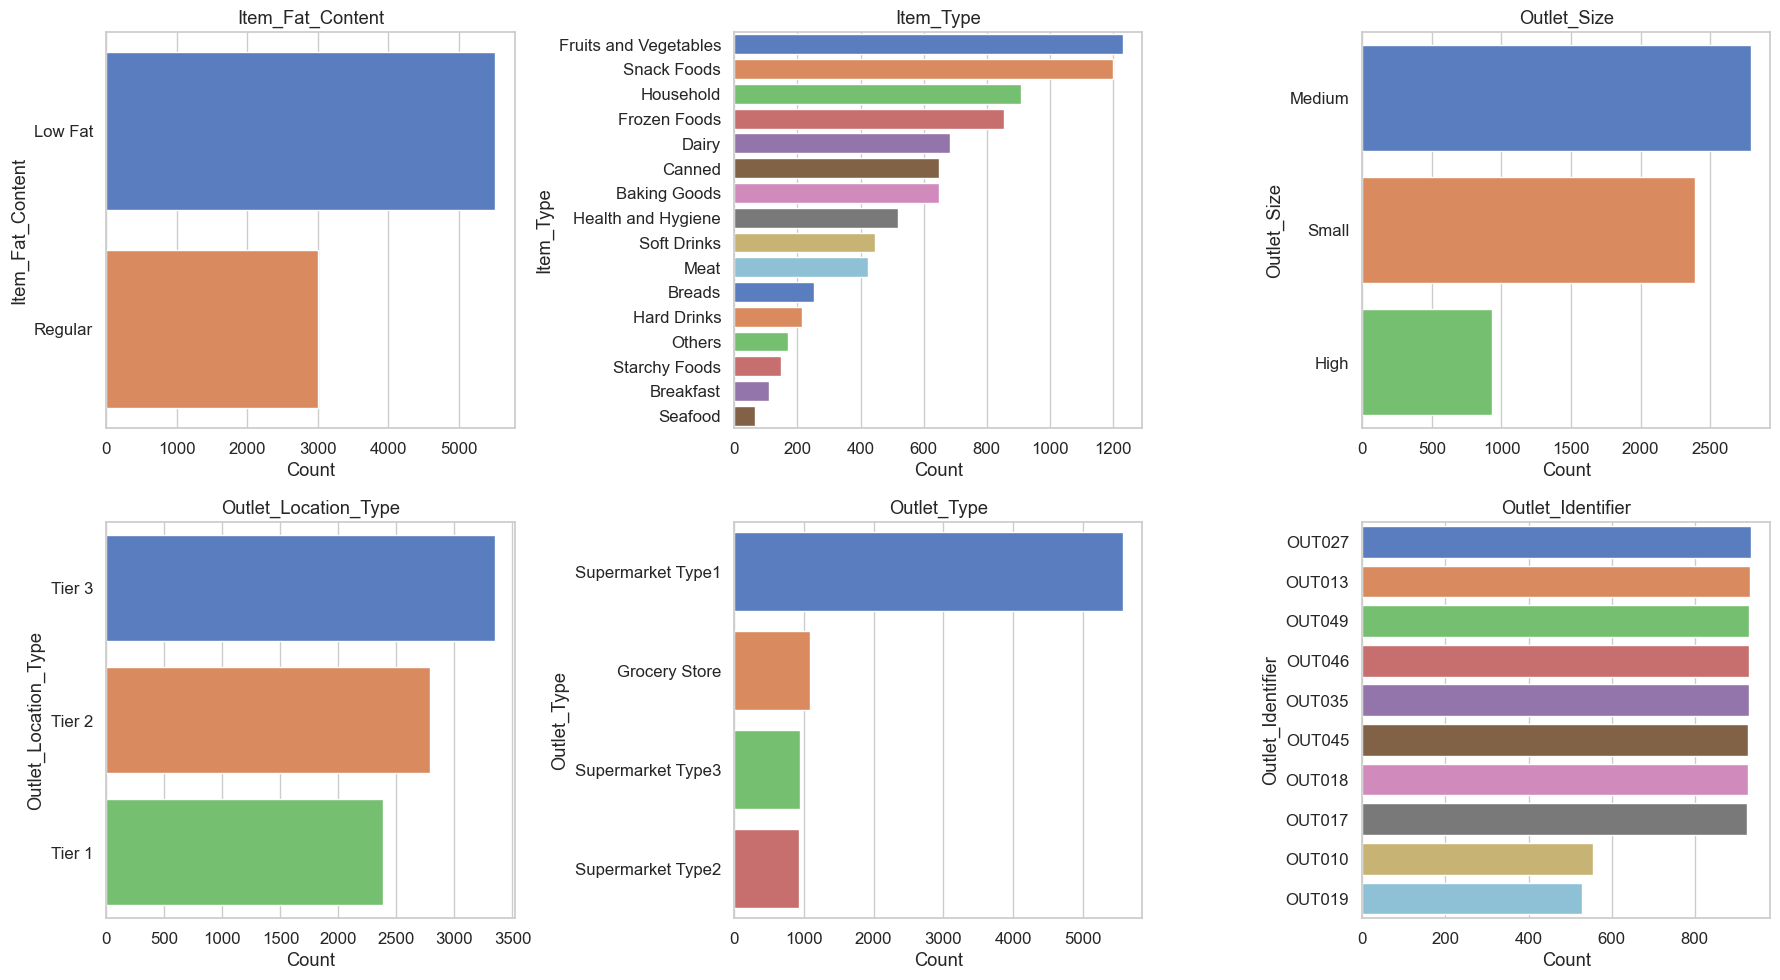

In [12]:
cat_cols = ['Item_Fat_Content','Item_Type','Outlet_Size',
            'Outlet_Location_Type','Outlet_Type','Outlet_Identifier']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train[col].value_counts().index
    sns.countplot(y=col, data=train, order=order, ax=ax, palette='muted')
    ax.set_title(col)
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()


## 5 · Numeric Features: Distributions & Outliers

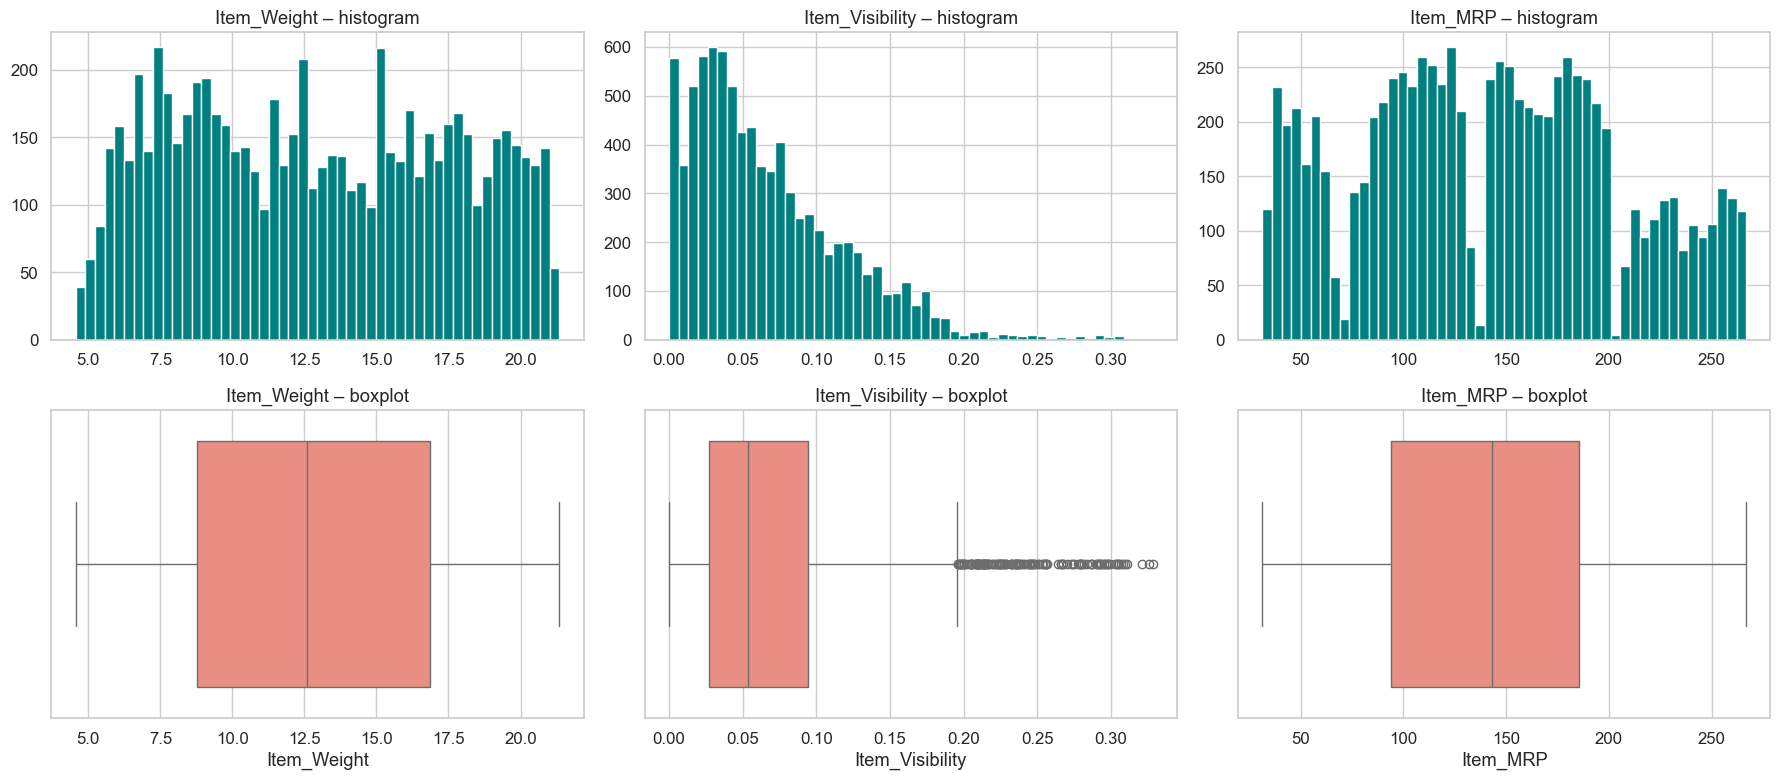

Zero visibility rows: 526


In [13]:
num_cols = ['Item_Weight','Item_Visibility','Item_MRP']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, col in enumerate(num_cols):
    train[col].hist(bins=50, ax=axes[0][i], color='teal', edgecolor='white')
    axes[0][i].set_title(f'{col} – histogram')
    
    sns.boxplot(x=train[col], ax=axes[1][i], color='salmon')
    axes[1][i].set_title(f'{col} – boxplot')

plt.tight_layout()
plt.show()

# Item_Visibility = 0 ?
print('Zero visibility rows:', (train['Item_Visibility'] == 0).sum())


## 6 · Sales vs. Categorical Features

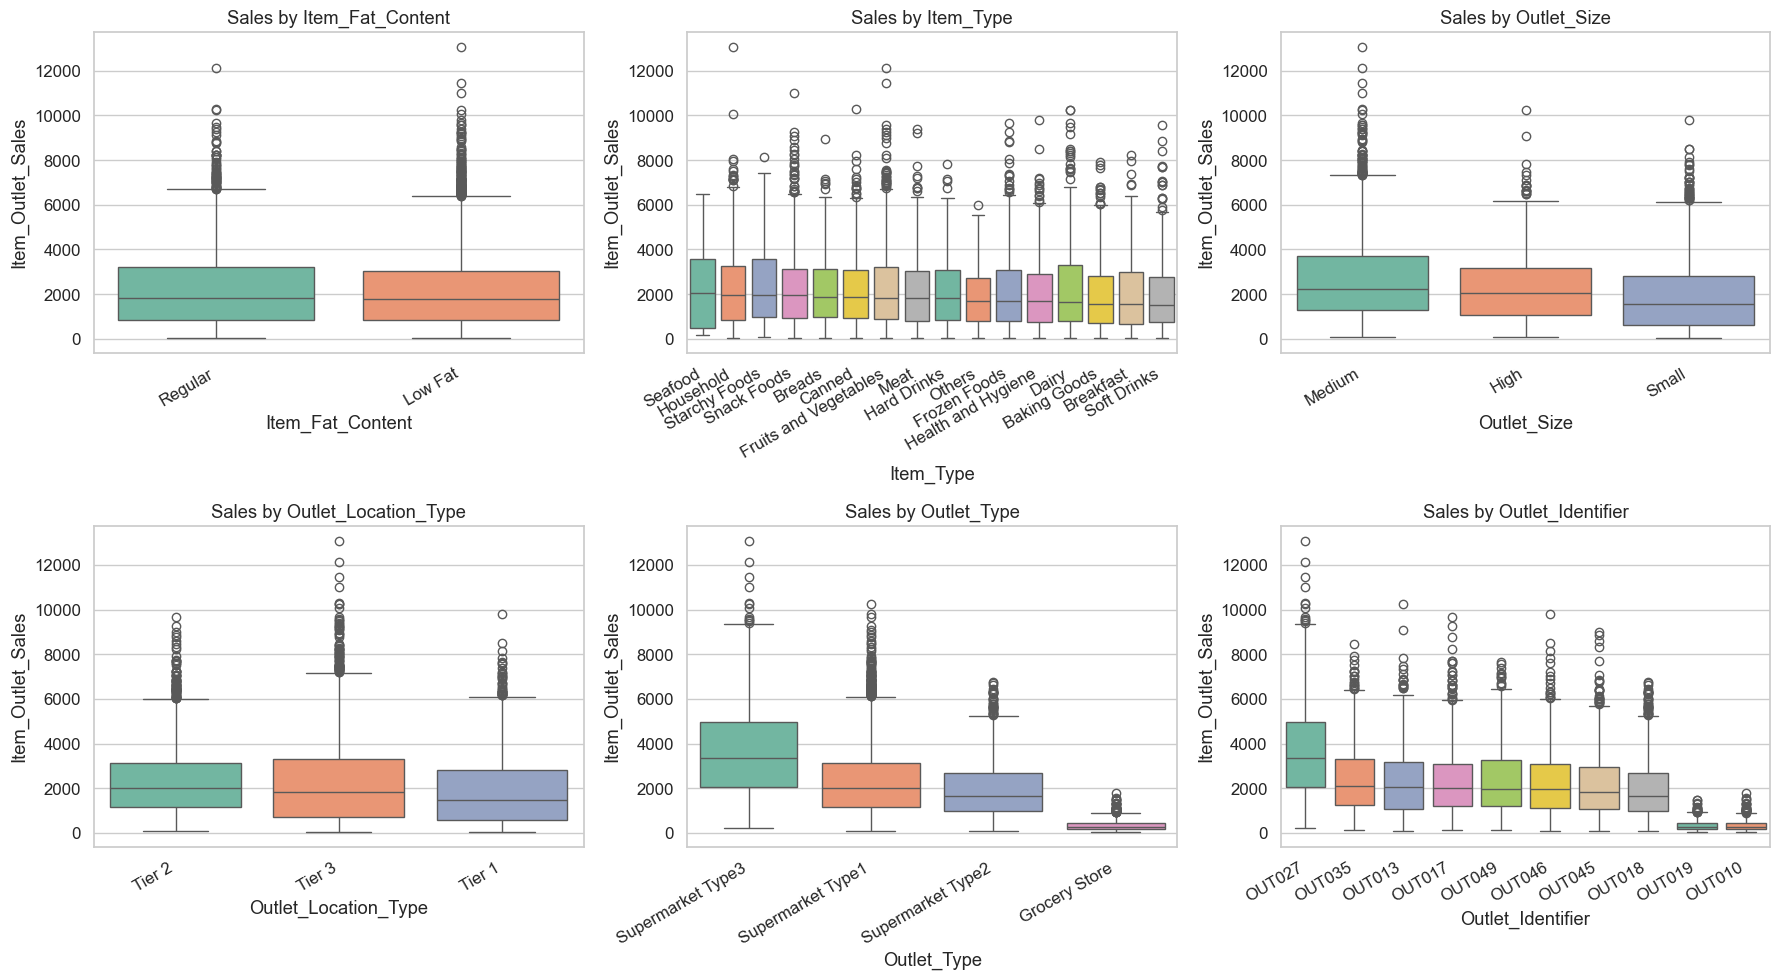

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train.groupby(col)['Item_Outlet_Sales'].median().sort_values(ascending=False).index
    sns.boxplot(x=col, y='Item_Outlet_Sales', data=train, order=order, ax=ax, palette='Set2')
    ax.set_title(f'Sales by {col}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 7 · Sales vs. Numeric Features

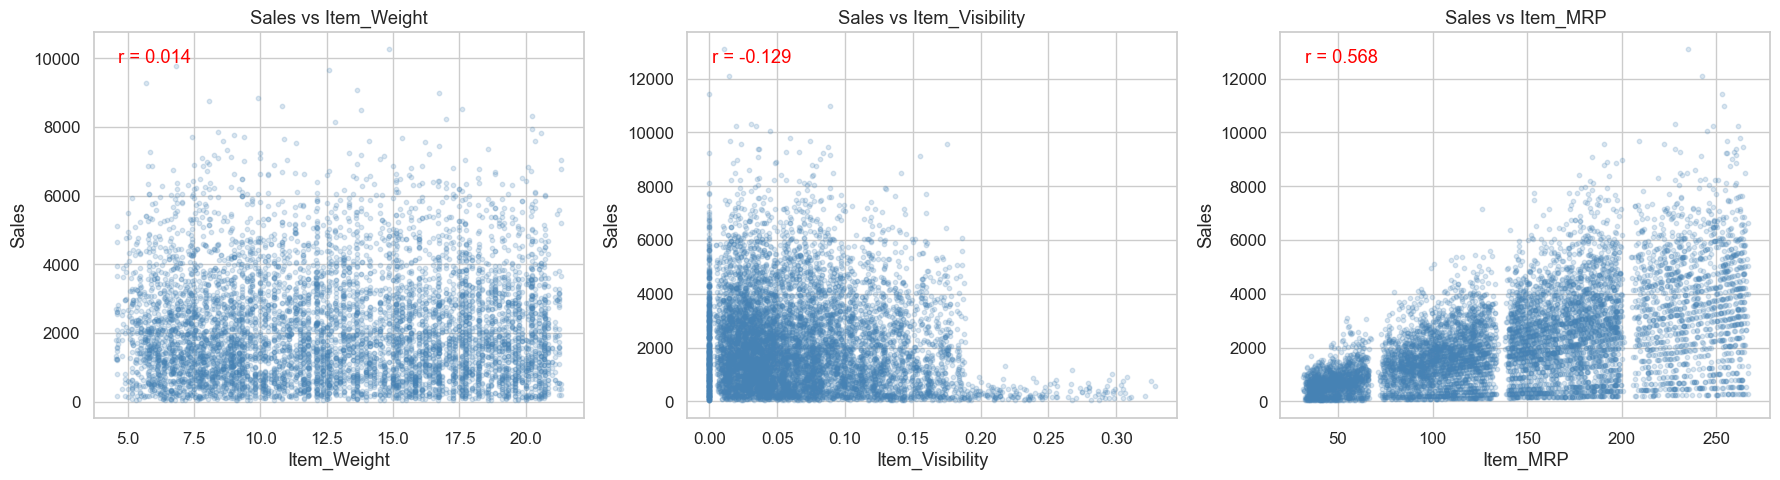

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    ax.scatter(train[col], train['Item_Outlet_Sales'], alpha=0.2, s=10, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Sales')
    ax.set_title(f'Sales vs {col}')
    # correlation
    r = train[[col,'Item_Outlet_Sales']].corr().iloc[0,1]
    ax.annotate(f'r = {r:.3f}', xy=(0.05,0.92), xycoords='axes fraction', color='red')
plt.tight_layout()
plt.show()


## 8 · Outlet-Level Analysis

In [16]:
outlet_sales = train.groupby('Outlet_Identifier')['Item_Outlet_Sales'].agg(['mean','median','sum','count'])
outlet_sales = outlet_sales.sort_values('mean', ascending=False)
print(outlet_sales.round(2))

outlet_info = train.drop_duplicates('Outlet_Identifier')[
    ['Outlet_Identifier','Outlet_Type','Outlet_Size','Outlet_Location_Type','Outlet_Establishment_Year']
].set_index('Outlet_Identifier')

outlet_combined = outlet_sales.join(outlet_info)
print()
print(outlet_combined)


                      mean   median         sum  count
Outlet_Identifier                                     
OUT027             3694.04  3364.95  3453926.05    935
OUT035             2438.84  2109.25  2268122.94    930
OUT049             2348.35  1966.11  2183969.81    930
OUT017             2340.68  2005.06  2167465.29    926
OUT013             2299.00  2050.66  2142663.58    932
OUT046             2277.84  1945.80  2118395.17    930
OUT045             2192.38  1834.94  2036725.48    929
OUT018             1995.50  1655.18  1851822.83    928
OUT019              340.33   265.32   179694.09    528
OUT010              339.35   250.34   188340.17    555

                          mean     median           sum  count  \
Outlet_Identifier                                                
OUT027             3694.038558  3364.9532  3.453926e+06    935   
OUT035             2438.841866  2109.2544  2.268123e+06    930   
OUT049             2348.354635  1966.1074  2.183970e+06    930   
OUT017   

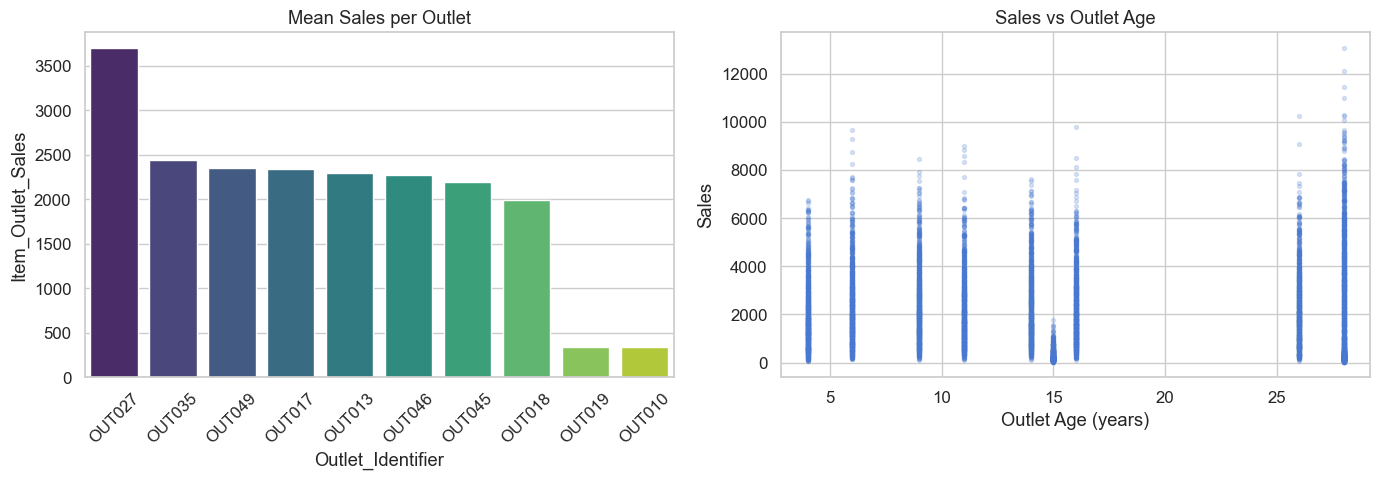

In [17]:
train['Outlet_Age'] = 2013 - train['Outlet_Establishment_Year']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = train.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean().sort_values(ascending=False).index
sns.barplot(x='Outlet_Identifier', y='Item_Outlet_Sales', data=train,
            order=order, ax=axes[0], palette='viridis', estimator='mean', errorbar=None)
axes[0].set_title('Mean Sales per Outlet')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

axes[1].scatter(train['Outlet_Age'], train['Item_Outlet_Sales'], alpha=0.2, s=8)
axes[1].set_xlabel('Outlet Age (years)')
axes[1].set_ylabel('Sales')
axes[1].set_title('Sales vs Outlet Age')
plt.tight_layout()
plt.show()


## 9 · Correlation Heatmap

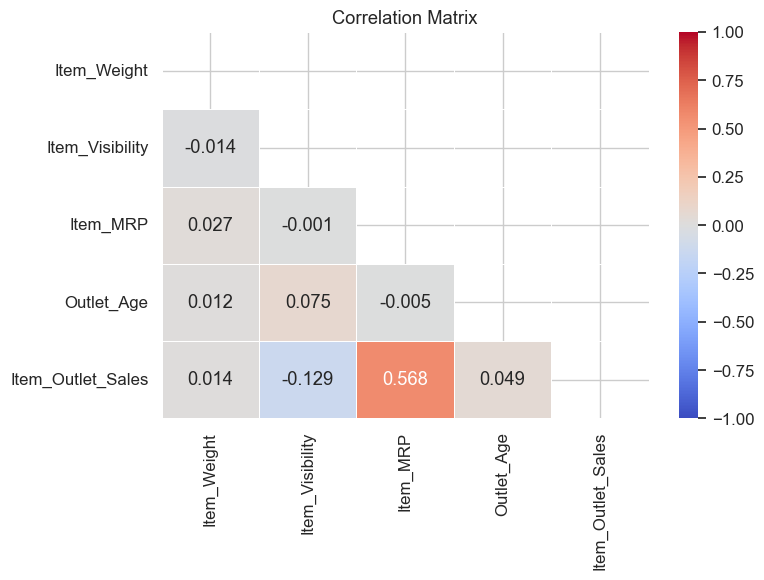

In [18]:
num_df = train[['Item_Weight','Item_Visibility','Item_MRP','Outlet_Age','Item_Outlet_Sales']].copy()
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()


## 10 · Item Identifier Prefix Patterns

Item prefix counts: {'FD': 6125, 'NC': 1599, 'DR': 799}


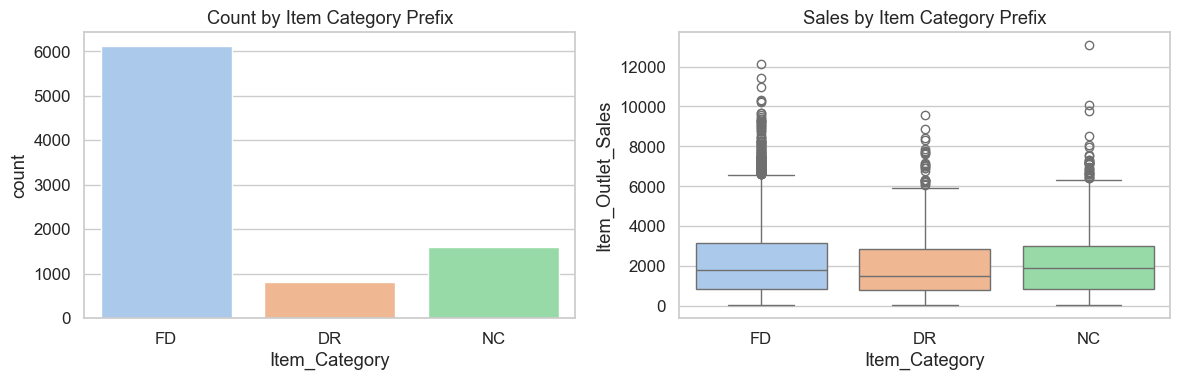

In [19]:
train['Item_Category'] = train['Item_Identifier'].str[:2]
print('Item prefix counts:', train['Item_Category'].value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Item_Category', data=train, ax=axes[0], palette='pastel')
axes[0].set_title('Count by Item Category Prefix')

sns.boxplot(x='Item_Category', y='Item_Outlet_Sales', data=train, ax=axes[1], palette='pastel')
axes[1].set_title('Sales by Item Category Prefix')
plt.tight_layout()
plt.show()


## 11 · Key Insights Summary

In [20]:
insights = {
    'Missing Item_Weight (%)': round(train['Item_Weight'].isnull().mean()*100, 2),
    'Missing Outlet_Size (%)': round(train['Outlet_Size'].isnull().mean()*100, 2),
    'Zero Item_Visibility rows': int((train['Item_Visibility']==0).sum()),
    'Fat content inconsistencies fixed': '5 → 2 categories',
    'Target skewness (raw)': round(train['Item_Outlet_Sales'].skew(), 3),
    'Target skewness (log1p)': round(np.log1p(train['Item_Outlet_Sales']).skew(), 3),
    'Strongest numeric correlator (MRP-r)': round(train['Item_MRP'].corr(train['Item_Outlet_Sales']), 3),
    'Outlet with highest mean sales': train.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean().idxmax(),
    'Outlet with lowest mean sales': train.groupby('Outlet_Identifier')['Item_Outlet_Sales'].mean().idxmin(),
}
for k, v in insights.items():
    print(f'  {k}: {v}')


  Missing Item_Weight (%): 17.17
  Missing Outlet_Size (%): 28.28
  Zero Item_Visibility rows: 526
  Fat content inconsistencies fixed: 5 → 2 categories
  Target skewness (raw): 1.178
  Target skewness (log1p): -0.882
  Strongest numeric correlator (MRP-r): 0.568
  Outlet with highest mean sales: OUT027
  Outlet with lowest mean sales: OUT010
